# bfloat16, int8 precision, and XProf profiling on TPU

CPU companion; no accelerator is required. TPU execution not validated.

- Measure numerical error for `bfloat16` matmuls with `float32` accumulation versus `bfloat16` accumulation.
- Implement per-channel `int8` weight quantization with `float32` rescaling and bound its error against an `fp32` reference.
- Capture a warmed `jax.profiler.trace` (`*.xplane.pb`) on a Cloud TPU VM (or local CPU rehearsal) after synchronizing warmup.
- Download the trace directory with `gcloud compute tpus tpu-vm scp --recurse` and inspect it in TensorBoard / XProf.

Casting activations and weights to `bfloat16` or `int8` halves or quarters memory traffic on a TPU, but careless accumulation in `bfloat16` or uncalibrated quantization silently degrades logits—and without a warmed `jax.profiler.trace` (`*.xplane.pb`), you cannot prove whether your TPU step is compute-bound, memory-bound, or waiting on the host.

## The idea

Always pair low-precision matmul operands (`bfloat16` or per-channel `int8`) with `preferred_element_type=jnp.float32` accumulation and measure numerical error against an `fp32` oracle; then wrap warmed steady-state steps in `with jax.profiler.trace(trace_dir):` and copy the `*.xplane.pb` trace back for XProf inspection.

## Why TPU matmuls use `bfloat16` operands with `float32` accumulation

`bfloat16` uses the same $8$-bit exponent range as `float32` (preventing underflow/overflow without loss scaling) but keeps only $7$ mantissa bits instead of $23$. When the TPU MXU multiplies two `bfloat16` matrices $X \in \mathbb{R}^{B \times K}$ and $W \in \mathbb{R}^{K \times N}$, accumulating the $K$ products in `float32` (`preferred_element_type=jnp.float32`) avoids compounding rounding error across the reduction dimension $K$.

For inference weight compression, symmetric per-channel `int8` quantization scales each output column $j$ by $s_j = \max_i |W_{i,j}| / 127$, stores $W^{(\text{int8})}_{i,j} = \text{clip}(\text{round}(W_{i,j}/s_j), -127, 127)$, and rescales the dot product in `float32`.

Finally, when profiling on a TPU VM with `jax.profiler.trace`, always execute and synchronize (`jax.block_until_ready`) one warmup call **before** entering the `with jax.profiler.trace(trace_dir):` block so the captured `*.xplane.pb` file shows steady-state device execution rather than XLA compilation.

### Pause and reason

Why does accumulating a dot product in `bfloat16` (`preferred_element_type=jnp.bfloat16`) have higher error than `preferred_element_type=jnp.float32` even when both inputs are `bfloat16`?

<details><summary>Compare your reasoning</summary>

When accumulating in `bfloat16`, every partial sum across the inner dimension `K` is rounded to 7 mantissa bits, whereas `float32` accumulation retains 23 mantissa bits for the entire reduction.

</details>

## 1. Capture a warmed XProf trace on your Cloud TPU VM and inspect in TensorBoard

Stage `public/exercises/tpu-06.py` to your Cloud TPU VM, run it inside `~/jax-tpu-lab/.venv` with `JAX_PLATFORMS=tpu`, copy the generated trace directory back with `gcloud compute tpus tpu-vm scp --recurse`, and open it in TensorBoard (`xprof`).

**Run tpu-06.py and capture a 5-step warmed XProf trace on the Cloud TPU VM**

```bash
# Run tpu-06.py and capture a 5-step warmed XProf trace on the Cloud TPU VM
gcloud compute tpus tpu-vm scp public/exercises/tpu-06.py "$TPU_NAME":~/jax-tpu-lab/ --zone="$ZONE"

gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" --command="
  set -euo pipefail
  source ~/jax-tpu-lab/.venv/bin/activate
  JAX_PLATFORMS=tpu python ~/jax-tpu-lab/tpu-06.py
  JAX_PLATFORMS=tpu python -c 'import jax, jax.numpy as jnp; x = jnp.ones((2048, 2048), dtype=jnp.bfloat16); fn = jax.jit(lambda a: jnp.dot(a, a, preferred_element_type=jnp.float32).astype(jnp.bfloat16)); jax.block_until_ready(fn(x)); jax.profiler.start_trace(\"/tmp/tpu-xprof-trace\"); [jax.block_until_ready(fn(x)) for _ in range(5)]; jax.profiler.stop_trace()'
"

gcloud compute tpus tpu-vm scp --recurse "$TPU_NAME":/tmp/tpu-xprof-trace ./tpu-xprof-trace --zone="$ZONE"
```

**Expected:** Executes tpu-06.py on the TPU VM, records a 5-step warmed XProf trace into /tmp/tpu-xprof-trace, and downloads the *.xplane.pb directory to ./tpu-xprof-trace.

**Launch TensorBoard with the XProf profile plugin on your workstation**

```bash
# Launch TensorBoard with the XProf profile plugin on your workstation
pip install tensorboard tensorboard-plugin-profile xprof
tensorboard --logdir ./tpu-xprof-trace --port 6006
```

**Expected:** Serves the XProf Trace Viewer, Overview Page, and Memory Viewer at http://localhost:6006.

## Compare BF16 (FP32 vs BF16 accumulation) and per-channel INT8 matmul errors

Create main.py with evaluate_precision_policies.

In [1]:
# Step 1 — Compare BF16 (FP32 vs BF16 accumulation) and per-channel INT8 matmul errors: Measuring both max and mean absolute error across accumulation...
# Import pathlib (Path) for this computation.
from pathlib import Path
import tempfile
import time
import jax
import jax.numpy as jnp
import numpy as np


# Function `evaluate_precision_policies(seed)` implementing this stage's computation:
def evaluate_precision_policies(seed=0):
    # Create or split explicit PRNG key(s) (`(k1, k2)`) for reproducible randomness.
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    # Sample deterministic random values into `x` using an explicit PRNG key.
    x = jax.random.normal(k1, (64, 256), dtype=jnp.float32)
    # Sample deterministic random values into `w` using an explicit PRNG key.
    w = jax.random.normal(k2, (256, 64), dtype=jnp.float32) * 0.25
    # Cast or evaluate `ref_fp32` in explicit floating-point precision.
    ref_fp32 = jnp.dot(x, w, preferred_element_type=jnp.float32)
    # Cast or evaluate `out_bf16_fp32acc` in explicit floating-point precision.
    out_bf16_fp32acc = jnp.dot(
        x.astype(jnp.bfloat16), w.astype(jnp.bfloat16), preferred_element_type=jnp.float32
    )
    # Cast or evaluate `out_bf16_bf16acc` in explicit floating-point precision.
    out_bf16_bf16acc = jnp.dot(
        x.astype(jnp.bfloat16), w.astype(jnp.bfloat16), preferred_element_type=jnp.bfloat16
    ).astype(jnp.float32)
    # Reduce across the target axis to summarize `scale`.
    scale = jnp.max(jnp.abs(w), axis=0, keepdims=True) / 127.0
    # Combine or mask array elements to form `w_int8`.
    w_int8 = jnp.clip(jnp.round(w / scale), -127, 127).astype(jnp.int8)
    # Cast or evaluate `out_int8_fp32acc` in explicit floating-point precision.
    out_int8_fp32acc = jnp.dot(x, w_int8.astype(jnp.float32) * scale, preferred_element_type=jnp.float32)
    # Evaluate `policies` from the current inputs and state.
    policies = [
        ("bf16 (fp32 accum)", out_bf16_fp32acc),
        ("bf16 (bf16 accum)", out_bf16_bf16acc),
        ("int8 per-col (fp32 accum)", out_int8_fp32acc),
    ]
    # Evaluate `results` from the current inputs and state.
    results = []
    # Loop over `(label, tensor)` in `policies`:
    for label, tensor in policies:
        # Run `jnp.abs` to compute `diff`.
        diff = jnp.abs(tensor - ref_fp32)
        # Reduce across the target axis to summarize ``.
        results.append({
            "policy": label,
            "max_abs_err": round(float(jnp.max(diff)), 5),
            "mean_abs_err": round(float(jnp.mean(diff)), 5),
        })
    # Return `results` to the caller.
    return results

Measuring both max and mean absolute error across accumulation dtypes quantifies why FP32 accumulation is standard on TPU MXUs.

## Capture a warmed XProf trace and verify *.xplane.pb output

Append capture_warmed_trace and the verification assertions to main.py.

In [2]:
# Step 2 — Capture a warmed XProf trace and verify *.xplane.pb output: Warming up before entering jax.profiler.trace ensures the captured...
def capture_warmed_trace(steps=4):
    # Initialize array `x` with explicit values and shape.
    x = jnp.ones((256, 256), dtype=jnp.bfloat16)
    # Wrap with `jax.jit` (`step_fn`) so XLA traces and compiles the function.
    step_fn = jax.jit(lambda a: jnp.dot(a, a, preferred_element_type=jnp.float32).astype(jnp.bfloat16))
    # Record execution timing or profiler trace in `t0`.
    t0 = time.perf_counter()
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(step_fn(x))
    # Record execution timing or profiler trace in `warmup_ms`.
    warmup_ms = (time.perf_counter() - t0) * 1000.0
    # Enter managed runtime/context scope for this block:
    with tempfile.TemporaryDirectory(prefix="tpu-course-trace-") as trace_dir:
        # Enter managed runtime/context scope for this block:
        with jax.profiler.trace(trace_dir):
            # Record execution timing or profiler trace in `t1`.
            t1 = time.perf_counter()
            # Repeat the update loop over `range(steps)` steps:
            for _ in range(steps):
                # Run `step_fn` to compute `x`.
                x = step_fn(x)
            # Synchronize host execution until asynchronous device computation completes.
            jax.block_until_ready(x)
            # Record execution timing or profiler trace in `steady_ms`.
            steady_ms = (time.perf_counter() - t1) * 1000.0 / steps
        # Read or serialize artifact data on disk (`xplane_files`).
        xplane_files = list(Path(trace_dir).rglob("*.xplane.pb"))
        # Return `{'warmup_ms': warmup_ms, 'steady_ms': steady_ms, 'xplane_count': len(xplane_files)}` to the caller.
        return {"warmup_ms": warmup_ms, "steady_ms": steady_ms, "xplane_count": len(xplane_files)}


# Run `evaluate_precision_policies` to compute `prec_table`.
prec_table = evaluate_precision_policies()
# Run `capture_warmed_trace` to compute `trace_info`.
trace_info = capture_warmed_trace()
# Verify contract: `trace_info['xplane_count'] >= 1`.
assert trace_info["xplane_count"] >= 1
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert prec_table[0]["max_abs_err"] < prec_table[1]["max_abs_err"]
# Print the observed values to compare against the expected result.
print("Precision comparison:", prec_table)
# Print diagnostic summary of the computed outputs.
print("Captured *.xplane.pb trace count:", trace_info["xplane_count"], "steady_ms:", round(trace_info["steady_ms"], 4))

Precision comparison: [{'policy': 'bf16 (fp32 accum)', 'max_abs_err': 0.03718, 'mean_abs_err': 0.00756}, {'policy': 'bf16 (bf16 accum)', 'max_abs_err': 0.05545, 'mean_abs_err': 0.00912}, {'policy': 'int8 per-col (fp32 accum)', 'max_abs_err': 0.12516, 'mean_abs_err': 0.02322}]
Captured *.xplane.pb trace count: 1 steady_ms: 0.0998


Warming up before entering jax.profiler.trace ensures the captured *.xplane.pb file records steady-state execution rather than first-call compilation.

## Run the example

In [3]:
# Step 1 — Compare BF16 (FP32 vs BF16 accumulation) and per-channel INT8 matmul errors: Measuring both max and mean absolute error across accumulation...
# Import pathlib (Path) for this computation.
from pathlib import Path
import tempfile
import time
import jax
import jax.numpy as jnp
import numpy as np


# Function `evaluate_precision_policies(seed)` implementing this stage's computation:
def evaluate_precision_policies(seed=0):
    # Create or split explicit PRNG key(s) (`(k1, k2)`) for reproducible randomness.
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    # Sample deterministic random values into `x` using an explicit PRNG key.
    x = jax.random.normal(k1, (64, 256), dtype=jnp.float32)
    # Sample deterministic random values into `w` using an explicit PRNG key.
    w = jax.random.normal(k2, (256, 64), dtype=jnp.float32) * 0.25
    # Cast or evaluate `ref_fp32` in explicit floating-point precision.
    ref_fp32 = jnp.dot(x, w, preferred_element_type=jnp.float32)
    # Cast or evaluate `out_bf16_fp32acc` in explicit floating-point precision.
    out_bf16_fp32acc = jnp.dot(
        x.astype(jnp.bfloat16), w.astype(jnp.bfloat16), preferred_element_type=jnp.float32
    )
    # Cast or evaluate `out_bf16_bf16acc` in explicit floating-point precision.
    out_bf16_bf16acc = jnp.dot(
        x.astype(jnp.bfloat16), w.astype(jnp.bfloat16), preferred_element_type=jnp.bfloat16
    ).astype(jnp.float32)
    # Reduce across the target axis to summarize `scale`.
    scale = jnp.max(jnp.abs(w), axis=0, keepdims=True) / 127.0
    # Combine or mask array elements to form `w_int8`.
    w_int8 = jnp.clip(jnp.round(w / scale), -127, 127).astype(jnp.int8)
    # Cast or evaluate `out_int8_fp32acc` in explicit floating-point precision.
    out_int8_fp32acc = jnp.dot(x, w_int8.astype(jnp.float32) * scale, preferred_element_type=jnp.float32)
    # Evaluate `policies` from the current inputs and state.
    policies = [
        ("bf16 (fp32 accum)", out_bf16_fp32acc),
        ("bf16 (bf16 accum)", out_bf16_bf16acc),
        ("int8 per-col (fp32 accum)", out_int8_fp32acc),
    ]
    # Evaluate `results` from the current inputs and state.
    results = []
    # Loop over `(label, tensor)` in `policies`:
    for label, tensor in policies:
        # Run `jnp.abs` to compute `diff`.
        diff = jnp.abs(tensor - ref_fp32)
        # Reduce across the target axis to summarize ``.
        results.append({
            "policy": label,
            "max_abs_err": round(float(jnp.max(diff)), 5),
            "mean_abs_err": round(float(jnp.mean(diff)), 5),
        })
    # Return `results` to the caller.
    return results


# Step 2 — Capture a warmed XProf trace and verify *.xplane.pb output: Warming up before entering jax.profiler.trace ensures the captured...
def capture_warmed_trace(steps=4):
    # Initialize array `x` with explicit values and shape.
    x = jnp.ones((256, 256), dtype=jnp.bfloat16)
    # Wrap with `jax.jit` (`step_fn`) so XLA traces and compiles the function.
    step_fn = jax.jit(lambda a: jnp.dot(a, a, preferred_element_type=jnp.float32).astype(jnp.bfloat16))
    # Record execution timing or profiler trace in `t0`.
    t0 = time.perf_counter()
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(step_fn(x))
    # Record execution timing or profiler trace in `warmup_ms`.
    warmup_ms = (time.perf_counter() - t0) * 1000.0
    # Enter managed runtime/context scope for this block:
    with tempfile.TemporaryDirectory(prefix="tpu-course-trace-") as trace_dir:
        # Enter managed runtime/context scope for this block:
        with jax.profiler.trace(trace_dir):
            # Record execution timing or profiler trace in `t1`.
            t1 = time.perf_counter()
            # Repeat the update loop over `range(steps)` steps:
            for _ in range(steps):
                # Run `step_fn` to compute `x`.
                x = step_fn(x)
            # Synchronize host execution until asynchronous device computation completes.
            jax.block_until_ready(x)
            # Record execution timing or profiler trace in `steady_ms`.
            steady_ms = (time.perf_counter() - t1) * 1000.0 / steps
        # Read or serialize artifact data on disk (`xplane_files`).
        xplane_files = list(Path(trace_dir).rglob("*.xplane.pb"))
        # Return `{'warmup_ms': warmup_ms, 'steady_ms': steady_ms, 'xplane_count': len(xplane_files)}` to the caller.
        return {"warmup_ms": warmup_ms, "steady_ms": steady_ms, "xplane_count": len(xplane_files)}


# Run `evaluate_precision_policies` to compute `prec_table`.
prec_table = evaluate_precision_policies()
# Run `capture_warmed_trace` to compute `trace_info`.
trace_info = capture_warmed_trace()
# Verify contract: `trace_info['xplane_count'] >= 1`.
assert trace_info["xplane_count"] >= 1
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert prec_table[0]["max_abs_err"] < prec_table[1]["max_abs_err"]
# Print the observed values to compare against the expected result.
print("Precision comparison:", prec_table)
# Print diagnostic summary of the computed outputs.
print("Captured *.xplane.pb trace count:", trace_info["xplane_count"], "steady_ms:", round(trace_info["steady_ms"], 4))

Precision comparison: [{'policy': 'bf16 (fp32 accum)', 'max_abs_err': 0.03718, 'mean_abs_err': 0.00756}, {'policy': 'bf16 (bf16 accum)', 'max_abs_err': 0.05545, 'mean_abs_err': 0.00912}, {'policy': 'int8 per-col (fp32 accum)', 'max_abs_err': 0.12516, 'mean_abs_err': 0.02322}]
Captured *.xplane.pb trace count: 1 steady_ms: 0.0901


Expected: Prints the precision error table (showing lower error for fp32 accumulation than bf16 accumulation) and confirms that at least one *.xplane.pb trace file was captured.

## Maximum and mean absolute matmul error across BF16 and INT8 precision policies

Predict: How do `bf16 (fp32 accum)`, `bf16 (bf16 accum)`, and `int8 per-col (fp32 accum)` compare in maximum and mean absolute error against an `fp32` reference?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [4]:
# Compute figure data for: Maximum and mean absolute matmul error across BF16 and INT8 precision policies
# Perform matrix contraction / projection to compute `visual_data`.
visual_data = {
    'kind': 'bar',
    'labels': [r['policy'] for r in prec_table],
    'xlabel': 'matmul precision policy',
    'ylabel': 'absolute error vs fp32 reference',
    'series': [
        {'label': 'max abs error', 'y': [float(r['max_abs_err']) for r in prec_table]},
        {'label': 'mean abs error', 'y': [float(r['mean_abs_err']) for r in prec_table]},
    ],
}

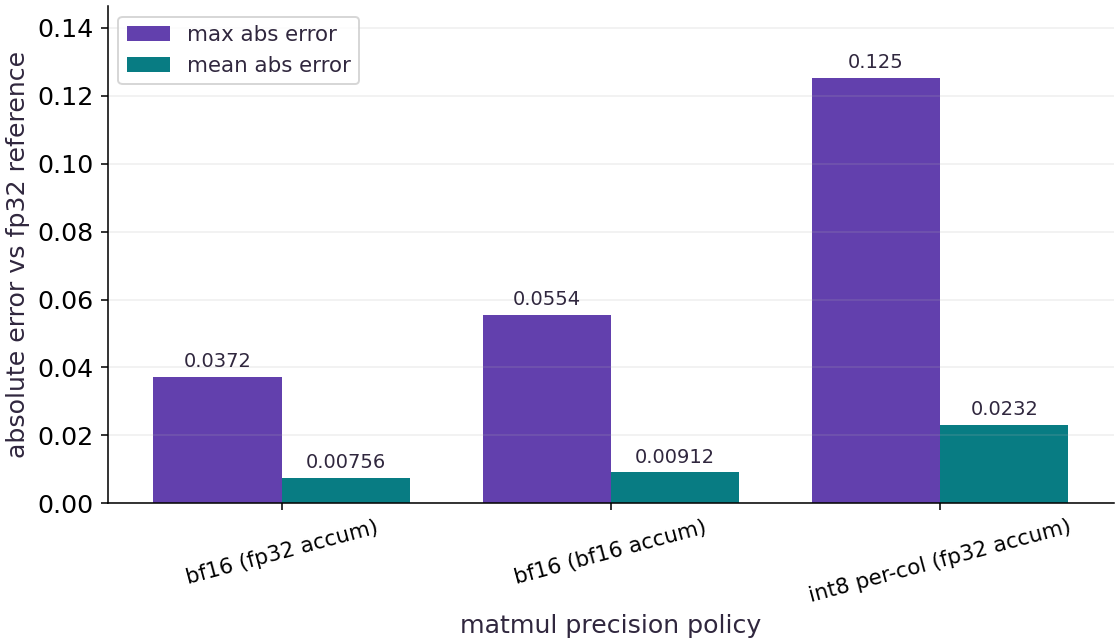

In [5]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis compares the three reduced-precision matmul policies. For each policy, the two bars report maximum absolute error and mean absolute error relative to an exact `float32` matrix multiplication.

### Connect it to the computation

Accumulating `bfloat16` inputs in `float32` cuts both mean and maximum error compared to `bfloat16` accumulation, while per-channel `int8` with `float32` accumulation keeps mean error small (`~0.01`) at one-quarter the weight bytes of `fp32`.

## Compare FP32 accumulation vs BF16 accumulation error ratio

Predict: How much larger is the maximum absolute error when accumulating BF16 matmuls in BF16 instead of FP32?

In [6]:
# Experiment — Compare FP32 accumulation vs BF16 accumulation error ratio: Passing preferred_element_type=jnp.float32 to jnp.dot or...
fp32_acc_err = prec_table[0]["max_abs_err"]
# Evaluate `bf16_acc_err` from the current inputs and state.
bf16_acc_err = prec_table[1]["max_abs_err"]
# Run `round` to compute `ratio`.
ratio = round(bf16_acc_err / fp32_acc_err, 2)
# Print the observed values to compare against the expected result.
print("BF16-accum / FP32-accum max error ratio:", ratio)
# Verify contract: `ratio > 1.3`.
assert ratio > 1.3

BF16-accum / FP32-accum max error ratio: 1.49


Expected: Accumulating in BF16 increases maximum absolute error by roughly $1.5\times$ compared to FP32 accumulation.

Passing `preferred_element_type=jnp.float32` to `jnp.dot` or `lax.dot_general` preserves FP32 accumulation on TPU.

## Compare warmup duration vs traced steady-state step duration

Predict: Does the warmup step outside the profiler take longer than the traced steady-state steps?

In [7]:
# Experiment — Compare warmup duration vs traced steady-state step duration: Keeping warmup outside jax.profiler.trace prevents XLA...
# Print the observed values to compare against the expected result.
print("Warmup ms:", round(trace_info["warmup_ms"], 3), "Traced steady step ms:", round(trace_info["steady_ms"], 4))
# Verify contract: `trace_info['warmup_ms'] > trace_info['steady_ms']`.
assert trace_info["warmup_ms"] > trace_info["steady_ms"]

Warmup ms: 20.498 Traced steady step ms: 0.0901


Expected: Warmup takes significantly longer than a single steady-state step inside the profiler block.

Keeping warmup outside `jax.profiler.trace` prevents XLA compilation from dominating the captured XProf timeline.

## Your exercise

Run `evaluate_precision_policies(seed=42)` and `capture_warmed_trace(steps=3)`, then verify that `bf16 (fp32 accum)` has strictly lower `mean_abs_err` than `bf16 (bf16 accum)` and that `xplane_count >= 1`.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `evaluate_precision_policies(...)` — Call `evaluate_precision_policies` with your updated parameters or inputs from this lesson's workspace.
- `capture_warmed_trace(...)` — Call `capture_warmed_trace` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run `capture_warmed_trace` to compute `t3`.
2. Print the observed values to compare against the expected result.
3. Verify contract: `p42[0]['mean_abs_err'] < p42[1]['mean_abs_err'] and t3['xplane_count...`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Run evaluate_precision_policies(seed=42) and...
p42 = evaluate_precision_policies(...)  # TODO: compute p42
# Run `capture_warmed_trace` to compute `t3`.
t3 = capture_warmed_trace(...)  # TODO: compute t3
# Print the observed values to compare against the expected result.
print("Seed 42 mean errors:", {r["policy"]: r["mean_abs_err"] for r in p42}, "xplane files:", t3["xplane_count"])
# Verify contract: `p42[0]['mean_abs_err'] < p42[1]['mean_abs_err'] and t3['xplane_count...`.
assert p42[0]["mean_abs_err"]  # TODO: complete assertion check
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Run evaluate_precision_policies(seed=42) and...
# p42 = evaluate_precision_policies(...)  # TODO: compute p42
# Run `capture_warmed_trace` to compute `t3`.
# t3 = capture_warmed_trace(...)  # TODO: compute t3
# Print the observed values to compare against the expected result.
# print("Seed 42 mean errors:", {r["policy"]: r["mean_abs_err"] for r in p42}, "xplane files:", t3["xplane_count"])
# Verify contract: `p42[0]['mean_abs_err'] < p42[1]['mean_abs_err'] and t3['xplane_count...`.
# assert p42[0]["mean_abs_err"]  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Run evaluate_precision_policies(seed=42) and...
p42 = evaluate_precision_policies(seed=42)
# Run `capture_warmed_trace` to compute `t3`.
t3 = capture_warmed_trace(steps=3)
# Print the observed values to compare against the expected result.
print("Seed 42 mean errors:", {r["policy"]: r["mean_abs_err"] for r in p42}, "xplane files:", t3["xplane_count"])
# Verify contract: `p42[0]['mean_abs_err'] < p42[1]['mean_abs_err'] and t3['xplane_count...`.
assert p42[0]["mean_abs_err"] < p42[1]["mean_abs_err"] and t3["xplane_count"] >= 1

Seed 42 mean errors: {'bf16 (fp32 accum)': 0.0075, 'bf16 (bf16 accum)': 0.00902, 'int8 per-col (fp32 accum)': 0.02182} xplane files: 1


## Compare per-channel vs per-tensor INT8 quantization error · Foundations

Quantize `w` with a single global scalar `scale_global = jnp.max(jnp.abs(w)) / 127.0` and compare its max error against per-channel quantization when one column of `w` is scaled by `10.0`.

Hint: Multiply `w[:, :1]` by `10.0` and compare per-column `axis=0` scale vs global scalar scale.

### How to write: Compare per-channel vs per-tensor INT8 quantization error — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jax.random.PRNGKey(seed) & jax.random.split(key)` — Manages explicit, stateless PRNG keys—always split a key before passing subkeys into independent random draws.

**Step-by-step implementation plan:**
1. Compare per-channel vs per-tensor INT8 quantization error (Foundations): One outlier channel stretches a per-tensor scale factor and...
2. Create or split explicit PRNG key(s) (`w_skew`) for reproducible randomness.
3. Evaluate `w_skew` from the current inputs and state.
4. Create or split explicit PRNG key(s) (`x_in`) for reproducible randomness.
5. Cast or evaluate `ref` in explicit floating-point precision.

**Starter code scaffold (fill in the TODOs):**

```python
# Compare per-channel vs per-tensor INT8 quantization error (Foundations): One outlier channel stretches a per-tensor scale factor and...
# Create or split explicit PRNG key(s) (`w_skew`) for reproducible randomness.
w_skew = jax.random.normal(...)  # TODO: compute w_skew
# Evaluate `w_skew` from the current inputs and state.
w_skew = ...  # TODO: compute w_skew
# Create or split explicit PRNG key(s) (`x_in`) for reproducible randomness.
x_in = jax.random.normal(...)  # TODO: compute x_in
# Cast or evaluate `ref` in explicit floating-point precision.
ref = jnp.dot(...)  # TODO: compute ref
# Reduce along axis=0 to compute `s_col`.
s_col = jnp.max(...)  # TODO: compute s_col
# Aggregate array values to compute `s_glb`.
s_glb = jnp.max(...)  # TODO: compute s_glb
# Combine or mask array elements to form `q_col`.
q_col = jnp.clip(...)  # TODO: compute q_col
# Combine or mask array elements to form `q_glb`.
q_glb = jnp.clip(...)  # TODO: compute q_glb
# Aggregate array values to compute `err_col`.
err_col = float(...)  # TODO: compute err_col
# Aggregate array values to compute `err_glb`.
err_glb = float(...)  # TODO: compute err_glb
# Print diagnostic summary of the computed outputs.
print("Mean error (per-channel vs per-tensor):", round(err_col, 5), round(err_glb, 5))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert err_col  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Compare per-channel vs per-tensor INT8 quantization error (Foundations): One outlier channel stretches a per-tensor scale factor and...
# Create or split explicit PRNG key(s) (`w_skew`) for reproducible randomness.
# w_skew = jax.random.normal(...)  # TODO: compute w_skew
# Evaluate `w_skew` from the current inputs and state.
# w_skew = ...  # TODO: compute w_skew
# Create or split explicit PRNG key(s) (`x_in`) for reproducible randomness.
# x_in = jax.random.normal(...)  # TODO: compute x_in
# Cast or evaluate `ref` in explicit floating-point precision.
# ref = jnp.dot(...)  # TODO: compute ref
# Reduce along axis=0 to compute `s_col`.
# s_col = jnp.max(...)  # TODO: compute s_col
# Aggregate array values to compute `s_glb`.
# s_glb = jnp.max(...)  # TODO: compute s_glb
# Combine or mask array elements to form `q_col`.
# q_col = jnp.clip(...)  # TODO: compute q_col
# Combine or mask array elements to form `q_glb`.
# q_glb = jnp.clip(...)  # TODO: compute q_glb
# Aggregate array values to compute `err_col`.
# err_col = float(...)  # TODO: compute err_col
# Aggregate array values to compute `err_glb`.
# err_glb = float(...)  # TODO: compute err_glb
# Print diagnostic summary of the computed outputs.
# print("Mean error (per-channel vs per-tensor):", round(err_col, 5), round(err_glb, 5))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert err_col  # TODO: complete assertion check

## Reference reasoning

One outlier channel stretches a per-tensor scale factor and crushes small channels into a few integer buckets; per-channel scaling isolates each column.

In [11]:
# Compare per-channel vs per-tensor INT8 quantization error (Foundations): One outlier channel stretches a per-tensor scale factor and...
# Create or split explicit PRNG key(s) (`w_skew`) for reproducible randomness.
w_skew = jax.random.normal(jax.random.PRNGKey(9), (128, 32), dtype=jnp.float32) * 0.2
# Evaluate `w_skew` from the current inputs and state.
w_skew = w_skew.at[:, 0].multiply(10.0)
# Create or split explicit PRNG key(s) (`x_in`) for reproducible randomness.
x_in = jax.random.normal(jax.random.PRNGKey(10), (32, 128), dtype=jnp.float32)
# Cast or evaluate `ref` in explicit floating-point precision.
ref = jnp.dot(x_in, w_skew, preferred_element_type=jnp.float32)
# Reduce along axis=0 to compute `s_col`.
s_col = jnp.max(jnp.abs(w_skew), axis=0, keepdims=True) / 127.0
# Aggregate array values to compute `s_glb`.
s_glb = jnp.max(jnp.abs(w_skew)) / 127.0
# Combine or mask array elements to form `q_col`.
q_col = jnp.clip(jnp.round(w_skew / s_col), -127, 127).astype(jnp.int8)
# Combine or mask array elements to form `q_glb`.
q_glb = jnp.clip(jnp.round(w_skew / s_glb), -127, 127).astype(jnp.int8)
# Aggregate array values to compute `err_col`.
err_col = float(jnp.mean(jnp.abs(jnp.dot(x_in, q_col.astype(jnp.float32) * s_col) - ref)))
# Aggregate array values to compute `err_glb`.
err_glb = float(jnp.mean(jnp.abs(jnp.dot(x_in, q_glb.astype(jnp.float32) * s_glb) - ref)))
# Print diagnostic summary of the computed outputs.
print("Mean error (per-channel vs per-tensor):", round(err_col, 5), round(err_glb, 5))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert err_col < err_glb

Mean error (per-channel vs per-tensor): 0.01389 0.0979


## Verify non-empty XProf *.xplane.pb byte size · Transfer / diagnosis

Capture a trace in a temporary directory and verify that the generated `*.xplane.pb` file has `stat().st_size > 0`.

Hint: Check `xplane_files[0].stat().st_size > 0`.

### How to write: Verify non-empty XProf *.xplane.pb byte size — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.
- `jax.block_until_ready(output)` — Synchronizes with the accelerator/CPU device so asynchronous dispatch finishes before wall-clock timing.

**Step-by-step implementation plan:**
1. Create an isolated temporary directory to run and inspect artifacts safely:
2. Initialize array `a` with explicit values and shape.
3. Wrap with `jax.jit` (`fn`) so XLA traces and compiles the function.
4. Synchronize host execution until asynchronous device computation completes.
5. Enter managed runtime/context scope for this block:

**Starter code scaffold (fill in the TODOs):**

```python
# Verify non-empty XProf *.xplane.pb byte size (Transfer / diagnosis): Verifying a non-empty *.xplane.pb file confirms the profiler...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-xplane-size-") as d:
    # Initialize array `a` with explicit values and shape.
    a = jnp.ones(...)  # TODO: compute a
    # Wrap with `jax.jit` (`fn`) so XLA traces and compiles the function.
    fn = jax.jit(...)  # TODO: compute fn
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(fn(a))
    # Enter managed runtime/context scope for this block:
    with jax.profiler.trace(d):
        # Synchronize host execution until asynchronous device computation completes.
        jax.block_until_ready(fn(a))
    # Read or serialize artifact data on disk (`pb`).
    pb = list(...)  # TODO: compute pb
    # Run `pb.stat` to compute `size_bytes`.
    size_bytes = pb.stat(...)  # TODO: compute size_bytes
# Print the observed values to compare against the expected result.
print("xplane.pb bytes:", size_bytes)
# Verify contract: `size_bytes > 0`.
assert size_bytes  # TODO: complete assertion check
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Verify non-empty XProf *.xplane.pb byte size (Transfer / diagnosis): Verifying a non-empty *.xplane.pb file confirms the profiler...
# Create an isolated temporary directory to run and inspect artifacts safely:
# with tempfile.TemporaryDirectory(prefix="tpu-xplane-size-") as d:
    # Initialize array `a` with explicit values and shape.
#     a = jnp.ones(...)  # TODO: compute a
    # Wrap with `jax.jit` (`fn`) so XLA traces and compiles the function.
#     fn = jax.jit(...)  # TODO: compute fn
    # Synchronize host execution until asynchronous device computation completes.
#     jax.block_until_ready(fn(a))
    # Enter managed runtime/context scope for this block:
#     with jax.profiler.trace(d):
        # Synchronize host execution until asynchronous device computation completes.
#         jax.block_until_ready(fn(a))
    # Read or serialize artifact data on disk (`pb`).
#     pb = list(...)  # TODO: compute pb
    # Run `pb.stat` to compute `size_bytes`.
#     size_bytes = pb.stat(...)  # TODO: compute size_bytes
# Print the observed values to compare against the expected result.
# print("xplane.pb bytes:", size_bytes)
# Verify contract: `size_bytes > 0`.
# assert size_bytes  # TODO: complete assertion check

## Reference reasoning

Verifying a non-empty `*.xplane.pb` file confirms the profiler flushed device and host events before closing.

In [13]:
# Verify non-empty XProf *.xplane.pb byte size (Transfer / diagnosis): Verifying a non-empty *.xplane.pb file confirms the profiler...
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix="tpu-xplane-size-") as d:
    # Initialize array `a` with explicit values and shape.
    a = jnp.ones((128, 128), dtype=jnp.bfloat16)
    # Wrap with `jax.jit` (`fn`) so XLA traces and compiles the function.
    fn = jax.jit(lambda z: z @ z)
    # Synchronize host execution until asynchronous device computation completes.
    jax.block_until_ready(fn(a))
    # Enter managed runtime/context scope for this block:
    with jax.profiler.trace(d):
        # Synchronize host execution until asynchronous device computation completes.
        jax.block_until_ready(fn(a))
    # Read or serialize artifact data on disk (`pb`).
    pb = list(Path(d).rglob("*.xplane.pb"))[0]
    # Run `pb.stat` to compute `size_bytes`.
    size_bytes = pb.stat().st_size
# Print the observed values to compare against the expected result.
print("xplane.pb bytes:", size_bytes)
# Verify contract: `size_bytes > 0`.
assert size_bytes > 0

xplane.pb bytes: 271921


## Checkpoint

Why should you run and synchronize at least one warmup step before entering `with jax.profiler.trace(trace_dir):` on a TPU VM?

1. Because `jax.profiler.trace` deletes all model weights if warmup is skipped
2. So the captured `*.xplane.pb` trace measures steady-state TPU execution and collective communication rather than one-time Python tracing and XLA HLO compilation
3. Because `bfloat16` only works inside a profiler context

## Diagnose

If XProf shows large gaps between device steps on your TPU VM, check for un-jitted Python work, host-side NumPy conversions, or synchronous `print(array)` calls inside the training step.

## Evidence

Keep the BF16 vs INT8 error summary, FP32-vs-BF16 accumulator drift comparison, and captured *.xplane.pb trace receipt.

## Carry forward

- Use `bfloat16` matmul operands with `preferred_element_type=jnp.float32` accumulation, and use per-channel scales when quantizing weights to `int8`.
- Capture warmed `jax.profiler.trace` (`*.xplane.pb`) artifacts on the TPU VM and copy them back with `gcloud compute tpus tpu-vm scp --recurse` before deleting the VM.

## Primary references

- [Profile JAX programs with XProf and TensorBoard](https://docs.jax.dev/en/latest/profiling.html)
- [Cloud TPU performance guide](https://cloud.google.com/tpu/docs/performance-guide)